#### 1. Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

#### 2. Load Dataset

In [3]:
df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


#### 3. Dataset Information

In [5]:
# Check number of rows and columns
print("Dataset Shape:", df.shape)

# Display dataset information
df.info()

# Display statistical summary
df.describe()

Dataset Shape: (200, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


#### 4. Check Missing Values

In [6]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

#### 5. Select Features

In [7]:
# Select Annual Income and Spending Score
# These features will be used for clustering

X = df.iloc[:, [3,4]]
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


#### 6. Visualize Data

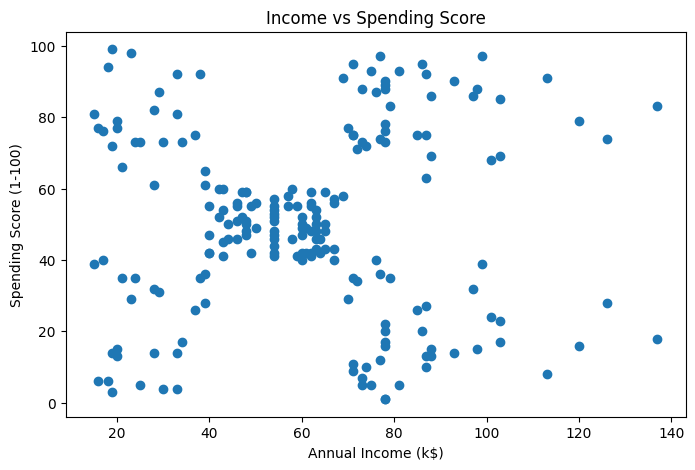

In [8]:
# Plot Income vs Spending Score

plt.figure(figsize=(8,5))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"]
)

plt.title("Income vs Spending Score")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")

plt.show()

#### 7. Finding Optimal Number of Clusters (Elbow Method)

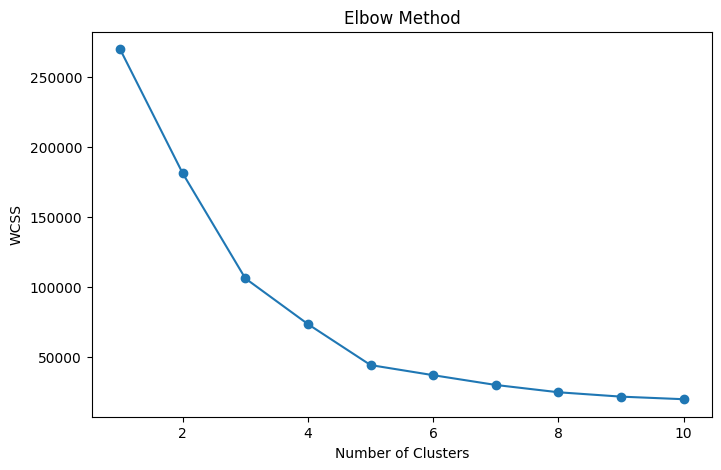

In [9]:
# Create empty list to store WCSS values
wcss = []

# Run KMeans for cluster values from 1 to 10
for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X)

    # Store WCSS value
    wcss.append(kmeans.inertia_)

# Plot Elbow Method graph
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()

In [10]:
# Observation:
# From the elbow graph, optimal number of clusters = 5

#### Apply K-Means Clustering

In [11]:
# Create KMeans model with 5 clusters
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

# Fit model and predict cluster labels
y_kmeans = kmeans.fit_predict(X)

#### 9. Visualize Customer Clusters

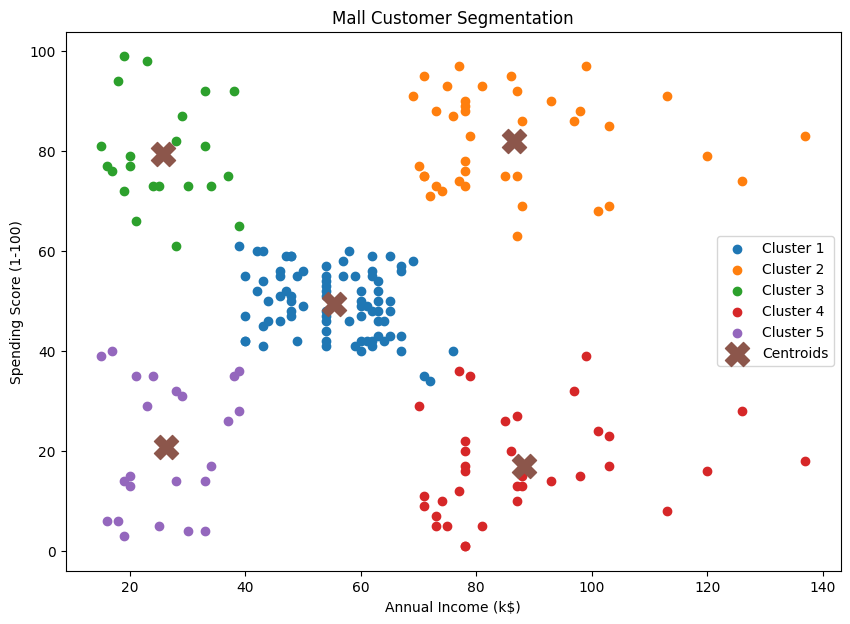

In [12]:
# Plot all clusters with different labels
plt.figure(figsize=(10,7))

plt.scatter(
    X.iloc[y_kmeans==0,0],
    X.iloc[y_kmeans==0,1],
    label="Cluster 1"
)

plt.scatter(
    X.iloc[y_kmeans==1,0],
    X.iloc[y_kmeans==1,1],
    label="Cluster 2"
)

plt.scatter(
    X.iloc[y_kmeans==2,0],
    X.iloc[y_kmeans==2,1],
    label="Cluster 3"
)

plt.scatter(
    X.iloc[y_kmeans==3,0],
    X.iloc[y_kmeans==3,1],
    label="Cluster 4"
)

plt.scatter(
    X.iloc[y_kmeans==4,0],
    X.iloc[y_kmeans==4,1],
    label="Cluster 5"
)

# Plot cluster centroids

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s=300,
    marker='X',
    label='Centroids'
)

plt.title("Mall Customer Segmentation")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()

plt.show()

#### 10. Add Cluster Labels to Dataset

In [13]:
# Add cluster labels as a new column
df["Cluster"] = y_kmeans

# Display updated dataset
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


#### 11. Analyze Clusters

In [14]:
# Calculate average values for each cluster

df.groupby("Cluster").mean(numeric_only=True)

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,
0,86.320988,42.716049,55.296296,49.518519
1,162.000000,32.692308,86.538462,82.128205
2,23.090909,25.272727,25.727273,79.363636
3,164.371429,41.114286,88.200000,17.114286
4,23.000000,45.217391,26.304348,20.913043


#### Final Conclusion

- 1. K-Means Clustering was used to segment mall customers.
- 2. Annual Income and Spending Score were used as features.
- 3. Elbow Method was used to find the optimal number of clusters.
- 4. Five customer groups were identified.
- 5. These groups can help businesses create targeted marketing strategies.